### Notebook 01 — ResNet-18 Baseline
### **DeepLense GSoC 2026 Evaluation**
### Train ResNet-18 from scratch on 1-channel 64×64 grayscale images.
### This is the lower-bound experiment — no pre-training, no augmentation.

In [1]:
# %% [Cell 1: Mount Google Drive & Set Workspace]
import os, sys
 
from google.colab import drive
drive.mount('/content/drive')
 
BASE_DIR = "/content/drive/My Drive/DeepLense_GSoC_Data"
SRC_DIR  = os.path.join(BASE_DIR, "src")
 
# Add src/ to path so we can import our modules
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
 
print(f"✅ Workspace : {BASE_DIR}")
print(f"✅ src/ path : {SRC_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Workspace : /content/drive/My Drive/DeepLense_GSoC_Data
✅ src/ path : /content/drive/My Drive/DeepLense_GSoC_Data/src


In [2]:
# %% [Cell 2: WandB Authentication — Key loaded from .env file]
import os
import wandb
from dotenv import load_dotenv

load_dotenv(os.path.join(BASE_DIR, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("✅ WandB authenticated successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diminiax (diminiax-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB authenticated successfully


In [3]:
# %% [Cell 3: Install Dependencies & Verify GPU]
# ── Install from pinned requirements — fixes numpy binary incompatibility ─
!pip install -q -r "/content/drive/My Drive/DeepLense_GSoC_Data/requirements.txt"

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")


🖥️  Device : cuda
   GPU    : Tesla T4


In [4]:
# %% [Cell 3: Imports & Reproducibility Seed]
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
 
# ── src/ module imports ───────────────────────────────────────────────────
from dataset import get_dataloaders, stage_data_locally
from models  import ResNetBaseline
from metrics import (
    save_confusion_matrix,
    generate_classification_report,
    plot_multiclass_roc_auc,
    plot_learning_curves,
)
 
# ── Reproducibility seed ──────────────────────────────────────────────────
def set_seed(seed=42):
    """Locks all random sources — required for reproducible ML4SCI evaluation."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
 
set_seed(42)
print("✅ Seed set to 42 — deterministic training enabled")

✅ Seed set to 42 — deterministic training enabled


In [5]:
# %% [Cell 4: Stage Data & Build DataLoaders]
ZIP_PATH = os.path.join(BASE_DIR, "dataset.zip")   # Path to your zip on Drive
CSV_NAME = "metadata.csv"
 
# ── Stage data locally ────────────────────────────────────────────────────
staged_dir = stage_data_locally(ZIP_PATH)
data_dir   = staged_dir if staged_dir else BASE_DIR
csv_path   = os.path.join(data_dir, CSV_NAME)
 
print(f"\n📂 Data directory : {data_dir}")
print(f"📄 CSV path       : {csv_path}")
 
# ── Build DataLoaders ─────────────────────────────────────────────────────
# Baseline config: grayscale ('L'), 64×64, NO augmentation
# FIX v1: val_transform is now SEPARATE from train_transform (no leakage)
# FIX v1: Normalization added (mean=0.5, std=0.5) — was missing in v1
# FIX v2: get_dataloaders now returns a 6-tuple (adds test_loader + test_df)
train_loader, val_loader, _, train_df, val_df, _ = get_dataloaders(
    csv_path   = csv_path,
    base_dir   = data_dir,
    mode       = 'L',       # Grayscale — 1 channel
    image_size = 64,        # Baseline uses 64×64
    batch_size = 32,
    augment    = False,     # No augmentation for clean baseline
)
 
print(f"\n✅ Train batches : {len(train_loader)} ({len(train_df)} images)")
print(f"✅ Val batches   : {len(val_loader)}   ({len(val_df)} images)")

📦 Staging data locally to '/content/local_dataset' for high-speed I/O...


✅ Data staging complete.

📂 Data directory : /content/local_dataset
📄 CSV path       : /content/local_dataset/metadata.csv

📊 Dataset Class Distribution:
   cdm        :   500 samples  (33.3%)
   no_sub     :   500 samples  (33.3%)
   vortex     :   500 samples  (33.3%)
   TOTAL      :  1500 samples

✅ Split — Train: 1050 | Val: 225 | Test: 225

✅ Train batches : 32 (1050 images)
✅ Val batches   : 8   (225 images)


In [6]:
# %% [Cell 5: Model, Loss, Optimizer, Scheduler]
# ── Model ─────────────────────────────────────────────────────────────────
model = ResNetBaseline(num_classes=3).to(device)
print(f"🧠 Model     : ResNetBaseline (weights=None)")
print(f"   Input     : (B, 1, 64, 64) — grayscale")
print(f"   Output    : (B, 3) — logits for [no_sub, cdm, vortex]")
 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Params    : {total_params:,}")
 
# ── Loss function ─────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
 
# ── Optimizer ─────────────────────────────────────────────────────────────
# Adam lr=1e-3 for training from scratch — higher than transfer learning
# because the model needs to learn feature extractors from zero
LEARNING_RATE = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
 
# ── LR Scheduler ─────────────────────────────────────────────────────────
# StepLR: multiply LR by 0.5 every 5 epochs
# Simple and predictable — suitable for training from scratch
EPOCHS    = 10
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
 
print(f"\n⚙️  Optimizer  : Adam (lr={LEARNING_RATE})")
print(f"⚙️  Scheduler  : StepLR (step=5, γ=0.5)")
print(f"⚙️  Epochs     : {EPOCHS}")
 
ASSETS_DIR  = os.path.join(BASE_DIR, "assets")
WEIGHTS_DIR = os.path.join(BASE_DIR, "weights")
os.makedirs(ASSETS_DIR,  exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

🧠 Model     : ResNetBaseline (weights=None)
   Input     : (B, 1, 64, 64) — grayscale
   Output    : (B, 3) — logits for [no_sub, cdm, vortex]
   Params    : 11,171,779

⚙️  Optimizer  : Adam (lr=0.001)
⚙️  Scheduler  : StepLR (step=5, γ=0.5)
⚙️  Epochs     : 10


In [7]:
# %% [Cell 6: Training Loop]
# ── History collectors ────────────────────────────────────────────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
 
best_val_acc = 0.0
best_epoch   = 0
best_weights = None
 
print(f"🚀 Starting Baseline Training — {EPOCHS} epochs\n")
 
for epoch in range(EPOCHS):
 
    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
 
    pbar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
 
        optimizer.zero_grad()
        logits = model(images)               # (B,3) raw logits
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
 
        t_loss    += loss.item()
        _, preds   = torch.max(logits, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*t_correct/t_total:.1f}%")
 
    train_loss = t_loss / len(train_loader)
    train_acc  = 100.0 * t_correct / t_total
 
    # ── VALIDATE ──────────────────────────────────────────────────────────
    # FIX v1: Validation runs every epoch (not just at the end)
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            v_loss    += criterion(logits, labels).item()
            _, preds   = torch.max(logits, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()
 
    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total
 
    # ── Scheduler step ────────────────────────────────────────────────────
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
 
    # ── Record history ────────────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    # ── Best checkpoint ───────────────────────────────────────────────────
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc  = val_acc
        best_epoch    = epoch + 1
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(WEIGHTS_DIR, "baseline_best.pth"))
 
    print(
        f"  Epoch {epoch+1:>2}/{EPOCHS} │ "
        f"Train  loss={train_loss:.4f}  acc={train_acc:.1f}% │ "
        f"Val  loss={val_loss:.4f}  acc={val_acc:.1f}% │ "
        f"LR={current_lr:.1e}"
        + (" ✅ best" if is_best else "")
    )
 
# Save final weights
torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "baseline_final.pth"))
print(f"\n💾 Final weights → weights/baseline_final.pth")
print(f"💾 Best weights  → weights/baseline_best.pth  (epoch {best_epoch}, val_acc={best_val_acc:.1f}%)")

🚀 Starting Baseline Training — 10 epochs



  Epoch  1/10 │ Train  loss=1.0299  acc=51.0% │ Val  loss=0.9947  acc=42.2% │ LR=1.0e-03 ✅ best


  Epoch  2/10 │ Train  loss=0.9216  acc=54.5% │ Val  loss=0.8907  acc=55.1% │ LR=1.0e-03 ✅ best


  Epoch  3/10 │ Train  loss=0.8661  acc=58.1% │ Val  loss=1.8231  acc=41.3% │ LR=1.0e-03


  Epoch  4/10 │ Train  loss=0.8566  acc=57.8% │ Val  loss=1.0201  acc=50.2% │ LR=1.0e-03


...

  Epoch  6/10 │ Train  loss=0.7756  acc=62.1% │ Val  loss=1.1066  acc=50.7% │ LR=5.0e-04


  Epoch  7/10 │ Train  loss=0.7407  acc=66.6% │ Val  loss=0.9110  acc=60.4% │ LR=5.0e-04 ✅ best


  Epoch  8/10 │ Train  loss=0.7289  acc=65.8% │ Val  loss=0.8503  acc=59.6% │ LR=5.0e-04


  Epoch  9/10 │ Train  loss=0.7104  acc=67.3% │ Val  loss=0.8923  acc=58.7% │ LR=5.0e-04


  Epoch 10/10 │ Train  loss=0.6914  acc=67.8% │ Val  loss=0.9521  acc=59.6% │ LR=2.5e-04

💾 Final weights → weights/baseline_final.pth
💾 Best weights  → weights/baseline_best.pth  (epoch 7, val_acc=60.4%)


📊 Learning curves saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/baseline_learning_curves.png


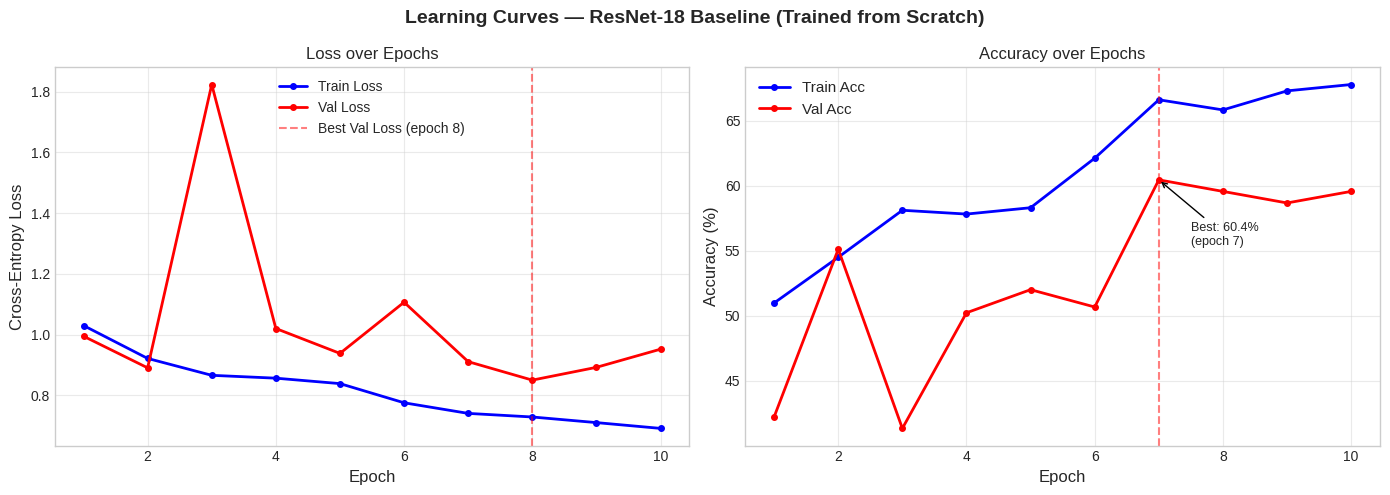

In [8]:
# %% [Cell 7: Learning Curves Plot]
plot_learning_curves(
    train_losses = train_losses,
    val_losses   = val_losses,
    train_accs   = train_accs,
    val_accs     = val_accs,
    save_path    = os.path.join(ASSETS_DIR, "baseline_learning_curves.png"),
    model_name   = "ResNet-18 Baseline (Trained from Scratch)",
)

In [9]:
# %% [Cell 8: Evaluation — Restore Weights & Run Inference]
# ── Load best weights directly from Drive — no retraining needed ──────────
print(f"🔄 Loading best weights from Drive → weights/baseline_best.pth")
model.load_state_dict(
    torch.load(os.path.join(WEIGHTS_DIR, "baseline_best.pth"), map_location=device)
)
model.eval()
print("✅ Weights loaded successfully")

# ── Collect predictions + probabilities ──────────────────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)                         # (B, 3) logits
        probs  = F.softmax(logits, dim=1)              # (B, 3) probabilities

        _, preds = torch.max(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
CLASSES   = ['No Sub', 'CDM', 'Vortex']

# ── Classification report ─────────────────────────────────────────────────
report = generate_classification_report(
    all_labels, all_preds,
    classes    = CLASSES,
    model_name = "ResNet-18 Baseline",
)

🔄 Loading best weights from Drive → weights/baseline_best.pth
✅ Weights loaded successfully

  CLASSIFICATION REPORT  —  ResNet-18 Baseline
              precision    recall  f1-score   support

      No Sub     0.5248    0.9867    0.6852        75
         CDM     0.6111    0.2933    0.3964        75
      Vortex     0.8333    0.5333    0.6504        75

    accuracy                         0.6044       225
   macro avg     0.6564    0.6044    0.5773       225
weighted avg     0.6564    0.6044    0.5773       225

  Macro F1        : 0.5773  ← use in result dicts
  Weighted F1     : 0.5773
  Macro Precision : 0.6564
  Macro Recall    : 0.6044



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/baseline_confusion_matrix.png


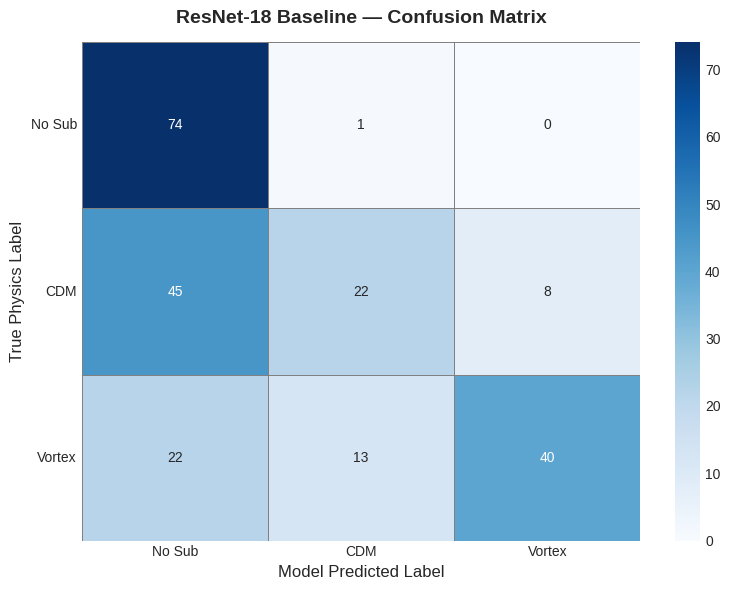


  ROC-AUC & PHYSICS REPORT  —  ResNet-18 Baseline (Trained from Scratch)
  No Sub      : AUC = 0.8537  |  FPR @ 90% TPR = 0.3000
  CDM         : AUC = 0.6375  |  FPR @ 90% TPR = 0.7200
  Vortex      : AUC = 0.8772  |  FPR @ 90% TPR = 0.3733
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.7863  |  FPR @ 90% TPR = 0.5200
  Macro-Avg   : AUC = 0.7895  |  FPR @ 90% TPR = 0.4644

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/baseline_roc_auc.png


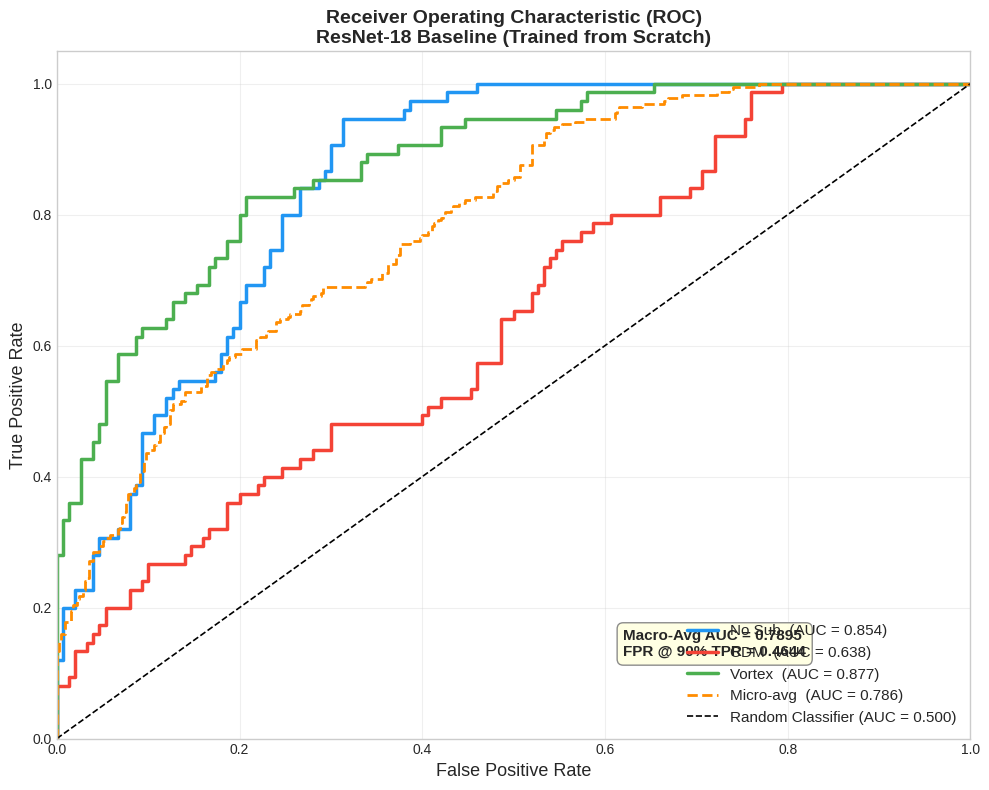

In [10]:
# %% [Cell 9: Confusion Matrix & ROC-AUC Plots]
save_confusion_matrix(
    all_labels, all_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "baseline_confusion_matrix.png"),
    title     = "ResNet-18 Baseline — Confusion Matrix",
    cmap      = "Blues",
)
 
auc_scores = plot_multiclass_roc_auc(
    all_labels, all_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "baseline_roc_auc.png"),
    model_name = "ResNet-18 Baseline (Trained from Scratch)",
)

In [11]:
# %% [Cell 10: Results Dict — Paste into Notebook 06]
# Store for the comparison table in Notebook 06
BASELINE_RESULTS = {
    'model':        'ResNet-18 Baseline',
    'val_acc':      best_val_acc,
    'macro_auc':    auc_scores['macro'],
    'cdm_auc':      auc_scores['per_class'][1],
    'fpr_90_macro': auc_scores['fpr_90_macro'],
    'f1_macro':     report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print("\n📌 BASELINE_RESULTS (paste into Notebook 06):")
print(BASELINE_RESULTS)
 


📌 BASELINE_RESULTS (paste into Notebook 06):
{'model': 'ResNet-18 Baseline', 'val_acc': 60.44444444444444, 'macro_auc': 0.7894518518518518, 'cdm_auc': 0.6375111111111111, 'fpr_90_macro': 0.46444444444444444, 'f1_macro': 0.5773293618822074}


In [12]:
# %% [Cell 11: Save Results to JSON — feeds NB06 automatically]
import json

RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "baseline_results.json"), "w") as f:
    json.dump(BASELINE_RESULTS, f, indent=2)

print("💾 Results saved → results/baseline_results.json")

💾 Results saved → results/baseline_results.json
